# LimeSeg Results

In [1]:
import open3d as o3d
import numpy as np
import sys
sys.path.append('../src')
import os

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [135]:
data_dir = "../data/Jake_Cropped"
shape = "74_S2"
mask_path = f"{data_dir}/{shape}_mask.mrc"
shape2 = f"{shape}_normalized_preprocessed"
original_path = f"{data_dir}/{shape2}.mrc"
limeseg_path = f"{data_dir}/{shape2}_LimeSeg.ply"

In [136]:
# Read Original data

import mrcfile
with mrcfile.open(original_path, permissive=True) as mrc:
    ori_data = mrc.data
with mrcfile.open(mask_path, permissive=True) as mrc:
    mask_data = mrc.data

In [137]:
# Read PLY
pcd = o3d.io.read_point_cloud(limeseg_path)
points = np.asarray(pcd.points)  # Nx3 numpy array

print("Point cloud shape:", points.shape)
print("Volume shape (Z, Y, X):", mask_data.shape)


Point cloud shape: (486, 3)
Volume shape (Z, Y, X): (70, 85, 85)


In [138]:
from scipy.ndimage import binary_dilation

def points_to_voxel_mask(points_xyz, volume_shape, radius=0):
    """
    points_xyz : (N,3) numpy array, assumed to be in voxel coordinates (X,Y,Z).
    volume_shape : (Z, Y, X)
    radius : >0이면 주변으로 dilation해서 surface를 두껍게.
    """
    zdim, ydim, xdim = volume_shape

    # (X,Y,Z) -> voxel index (z,y,x)
    x = np.round(points_xyz[:, 0]).astype(int)
    y = np.round(points_xyz[:, 1]).astype(int)
    z = np.round(points_xyz[:, 2]).astype(int)

    # 유효한 인덱스만 사용
    valid = (
        (z >= 0) & (z < zdim) &
        (y >= 0) & (y < ydim) &
        (x >= 0) & (x < xdim)
    )
    z = z[valid]
    y = y[valid]
    x = x[valid]

    mask = np.zeros(volume_shape, dtype=bool)
    mask[z, y, x] = True

    if radius > 0:
        # 구(구형) structuring element 생성
        r = int(radius)
        zz, yy, xx = np.mgrid[-r:r+1, -r:r+1, -r:r+1]
        selem = (xx**2 + yy**2 + zz**2) <= r**2
        mask = binary_dilation(mask, structure=selem)

    return mask

In [139]:
limeseg_mask = points_to_voxel_mask(points, mask_data.shape, radius=2)  

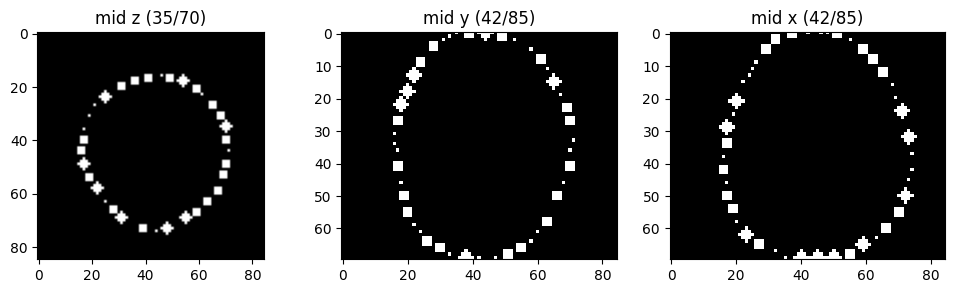

In [140]:
from pinn.plot import _to_zyx, visualize_zyx_midslice, visualize_zyx_midslice_vs_overlay

visualize_zyx_midslice(limeseg_mask)

In [141]:
from pinn.checkpoint_io import load_checkpoint_at_step
from pinn.analysis import dice_loss_pinn_vs_mask
from pinn.grid import phi_on_cryo_grid_xyz
from pinn.plot import _to_zyx
from pinn.train import create_train_state
from pinn.model import PINN, EPSILON, LEARNING_RATE, WEIGHT_IN
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def dice_loss_pinn_vs_limeseg(mask_file_path, limeseg_mask, checkpoint, band=(-0.8, 0.8), verbose=True):
    from pinn.grid import phi_on_cryo_grid_xyz
    from pinn.plot import _to_zyx
    with mrcfile.open(mask_file_path, permissive=True) as mrc:
        gt_mask = np.asarray(mrc.data, dtype=np.float32)
    gt_mask = np.where(gt_mask > 0.5, 1, 0)

    state = checkpoint["state"]; params = state["params"]
    model = PINN()
    phi_fn = lambda x: model.apply(params, x.reshape(-1, 3))
    phi_xyz, _, _ = phi_on_cryo_grid_xyz(phi_fn, gt_mask.shape, lo=-1.0, hi=1.0)
    phi_zyx = _to_zyx(np.array(phi_xyz))  
    lo, hi = band
    pred_mask = (phi_zyx > lo) & (phi_zyx < hi)

    if pred_mask.shape != gt_mask.shape:
        raise ValueError(f"Shape mismatch: pred {pred_mask.shape} vs gt {gt_mask.shape}")
    
    intersection = np.count_nonzero(gt_mask & pred_mask)
    gt_sum = np.count_nonzero(gt_mask)
    pd_sum = np.count_nonzero(pred_mask)
    volume_sum = gt_sum + pd_sum
    dice = (2.0 * intersection) / (volume_sum + 1e-8)

    fig, axes = plt.subplots(3, 4, figsize=(12, 12))  # 4행 3열

    # 슬라이스 인덱스 계산
    x_indices = np.linspace(0, gt_mask.shape[2] - 1, 6, dtype=int)
    y_indices = np.linspace(0, gt_mask.shape[1] - 1, 6, dtype=int)
    z_indices = np.linspace(0, gt_mask.shape[0] - 1, 6, dtype=int)

    magenta = ListedColormap([[0,0,0,0], [1,0,1,1]])
    lime = ListedColormap([[0,0,0,0], [0,1,0,1]])

    # 각 방향별 슬라이스 시각화
    for i in range(1, 5):
        # Z-slice
        z = z_indices[i]
        gt_z = gt_mask[z, :, :]
        pd_z = pred_mask[z, :, :]
        lime_z = limeseg_mask[z, :, :]
        axes[0, i-1].imshow(gt_z, cmap="gray", alpha=1.0)
        axes[0, i-1].imshow(pd_z, cmap=magenta, alpha=0.5)
        axes[0, i-1].imshow(lime_z, cmap=lime, alpha=0.5)
        axes[0, i-1].set_title(f"Z-slice {z}")
        axes[0, i-1].axis("off")

        # Y-slice
        y = y_indices[i]
        gt_y = gt_mask[:, y, :]
        pd_y = pred_mask[:, y, :]
        lime_y = limeseg_mask[:, y, :]
        axes[1, i-1].imshow(gt_y, cmap="gray", alpha=1.0)
        axes[1, i-1].imshow(pd_y, cmap=magenta, alpha=0.5)
        axes[1, i-1].imshow(lime_y, cmap=lime, alpha=0.5)
        axes[1, i-1].set_title(f"Y-slice {y}")
        axes[1, i-1].axis("off")

        # X-slice
        x = x_indices[i]
        gt_x = gt_mask[:, :, x]
        pd_x = pred_mask[:, :, x]
        lime_x = limeseg_mask[:, :, x]
        axes[2, i-1].imshow(gt_x, cmap="gray", alpha=1.0)
        axes[2, i-1].imshow(pd_x, cmap=magenta, alpha=0.5)
        axes[2, i-1].imshow(lime_x, cmap=lime, alpha=0.5)
        axes[2, i-1].set_title(f"X-slice {x}")
        axes[2, i-1].axis("off")

    plt.suptitle("White = GT Mask, Magenta = PINN, Lime = LimeSeg", fontsize=16)
    plt.tight_layout()
    plt.show()

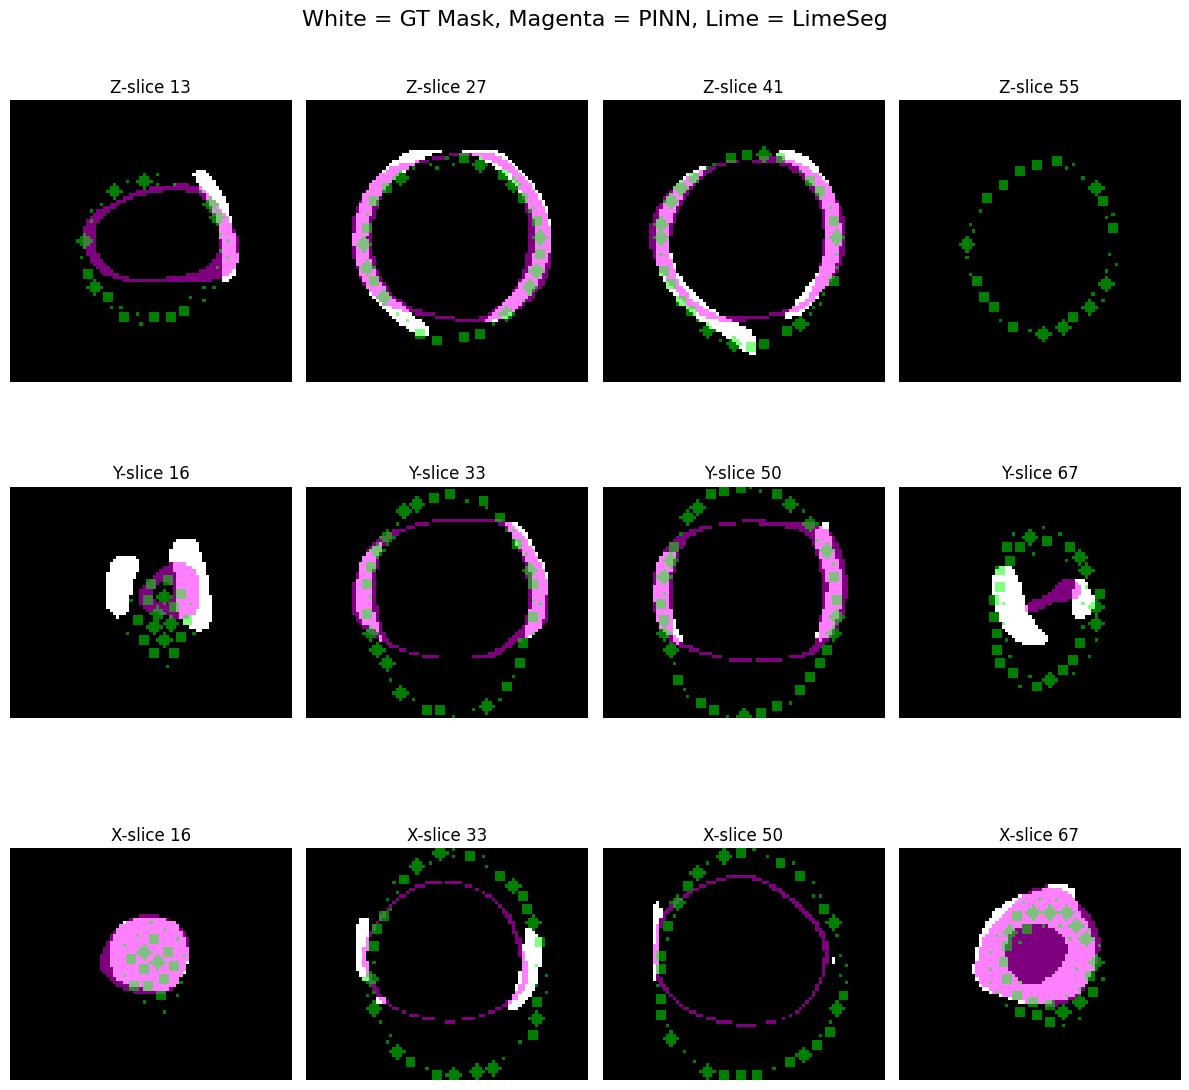

None


In [142]:
lambda_1 = 4000000
lambda_2 = 300

checkpoint_dir = os.path.abspath(
    f"../outputs/logs/{shape2}/lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}/checkpoint"
)

checkpoint_data = load_checkpoint_at_step(5000, checkpoint_dir, lambda_1, lambda_2)
state = checkpoint_data["state"]; params = state["params"]

checkpoint_data = load_checkpoint_at_step(5000, checkpoint_dir, lambda_1, lambda_2)
dice_loss_pinn = dice_loss_pinn_vs_limeseg(mask_path, limeseg_mask, checkpoint_data, band=(-0.7, 0.7), verbose=True)
print(dice_loss_pinn)